# Training and Evaluating a Tree Classifier

In [1]:

import os, math, random, joblib
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from collections import defaultdict
from datetime import datetime

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter


## Définition des variables globales
Définissons quelques variables utiles au niveau global et fixons également l'état aléatoire pour tous les processus nécessitant une valeur de départ aléatoire.

#### Que signifie « random_state » ?

De nombreuses étapes de l'apprentissage automatique font appel au hasard, comme le brassage des données ou l'initialisation des poids et des biais d'un nouveau modèle. Le paramètre `random_state` contrôle ce caractère aléatoire en définissant une valeur de départ fixe pour le générateur de nombres aléatoires.

Lorsque `random_state` est défini sur un entier spécifique (par exemple, 42), la même séquence d'opérations « aléatoires » est utilisée à chaque exécution du code. Cela garantit que les découpages de l'ensemble de données et les autres étapes aléatoires sont reproductibles, ce qui est essentiel pour le débogage, la comparaison équitable des modèles et le partage des résultats.

La valeur `42` est couramment utilisée par convention, mais elle n'a aucune signification particulière : n'importe quel entier fixe fonctionnerait tout aussi bien.

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
SEED = 42
seed_everything(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device that will be used to run:", DEVICE)
PARQUET_PATH = "https://drive.google.com/uc?export=download&id=1eEhK6wZzaRLeQAgDTFC8fuGj9bVN6gev"
SAMPLE_CSV = "https://drive.google.com/uc?export=download&id=1VCfKiLhwAQfyQscuYJ3U12mNj8c4NFUP"
RUN_DIR = "runs"
CHECKPOINT = "tree_net.pt"
SCALER_PATH = "tree_scaler.joblib"
# # Pour exécuter dans Google Colab, il faut identifier un dossier sur votre Google Drive pour ces opérations :
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True) # l'exécution de cette commande vous demandera l’autorisation d’accéder à votre Drive, si c’est votre première utilisation.
# RUN_DIR = "/content/drive/MyDrive/Colab Notebooks/Tutorial_2/runs" # Ce dossier doit exister dans votre Drive
# CHECKPOINT = "/content/drive/MyDrive/Colab Notebooks/Tutorial_2/ckpts/tree_net.pt" # Le dossier racine de ce fichier doit exister dans votre Drive
# SCALER_PATH = "/content/drive/MyDrive/Colab Notebooks/Tutorial_2/ckpts/tree_scaler.joblib" #  dossier racine de ce fichier doit exister dans votre Drive
BATCHSIZE = 8192
EPOCHS = 5

device that will be used to run: cuda


## Étalonnage approprié des variables

✅ MinMaxScaler pour X_WGS84, Y_WGS84

Les coordonnées longitude/latitude sont limitées et représentent une position absolue appropriée.

La standardisation détruit la structure « en boîte » de l’espace.

Le min–max conserve l’intégrité géométrique des données et permet au réseau de traiter de façon cohérente les distances spatiales.

Cela prévient les anomalies lors de la prédiction sur des lieux voisins qui n’ont pas été vus par le modèle.

"Les coordonnées ne sont pas des mesures centrées autour d’une moyenne : elles définissent une localisation."

✅ StandardScaler pour boa (réflectances Sentinel-2)

Les bandes BOA (Bottom Of Atmosphere, réflectance corrigée des effets atmosphériques):

- sont continues,
- ont une distribution à peu près gaussienne suite à la correction atmosphérique,
- sont comparables entre scènes une fois normalisées.

La normalisation facilite l’optimisation (notamment avec des réseaux ReLU).

Même si les valeurs de réflectance sont initialement situées entre 0 et 10 000, il est préférable de les normaliser plutôt que de simplement les mettre à l’échelle, surtout lorsqu’on les combine avec d’autres variables.

“Les caractéristiques spectrales présentent des gradients plus stables lorsqu’elles sont standardisées avec une moyenne nulle et une variance unitaire.”


✅ StandardScaler pour le jour de l'année (DOY: Day of Year)

On commence par convertir en variables cycliques :

doy → sin(2πdoy/365), cos(2πdoy/365)


Ces variables sont comprises dans l'intervalle [-1, 1].

Le StandardScaler recentre les petits biais saisonniers.

Le MinMaxScaler ne respecterait pas la symétrie circulaire.


✅ RobustScaler pour dbh_mm, height_dm, crown_area_m2

Ces variables :

- sont strictement positives
- ont souvent une distribution étirée vers la droite (grandes valeurs positives)
- contiennent des valeurs extrêmes (grands arbres, peuplements anciens)

Le RobustScaler (médiane + écart interquartile) :

- préserve la structure des rangs
- évite que les arbres les plus grands et les plus rares dominent l'entrainement du modèle

« Les structures forestières comportent des valeurs extrêmes; les statistiques robustes sont moins sensibles et plus sûres »

✅ NDVI?

Deux options envisageables:

StandardScaler (recommandé lorsque le NDVI ne présente pas d’anomalies)

RobustScaler (en cas de risque de saturation ou de présence d’artefacts liés au capteur)


In [3]:
def add_time_features(df):
    doy = df["doy"].astype(np.float32).values
    ang = 2 * np.pi * (doy / 365.0)
    df = df.copy()
    df["doy_sin"] = np.sin(ang).astype(np.float32)
    df["doy_cos"] = np.cos(ang).astype(np.float32)
    return df

In [4]:
class TreeFeatureScaler:
    """
    Scaler for heterogeneous tree features with leakage-safe fitting.

    - MinMaxScaler: coordinates (X_WGS84, Y_WGS84)
    - RobustScaler: structural features (dbh, height, crown area)
    - StandardScaler: BOA, NDVI, cyclic DOY features
    """

    def __init__(
            self,
            coord_cols=("X_WGS84", "Y_WGS84"),
            struct_cols=("dbh_mm", "height_dm", "crown_area_m2"),
            veg_cols=("ndvi",),
            time_cols=("doy_sin", "doy_cos"),
            boa_cols=("Blue", "Green", "Red", "B05", "B06", "B07", "NIR", "B8a", "SWIR1", "SWIR2"),
    ):
        self.coord_cols = list(coord_cols)
        self.struct_cols = list(struct_cols)
        self.veg_cols = list(veg_cols)
        self.time_cols = list(time_cols)
        self.boa_cols = list(boa_cols)

        # scalers (initialized but not fitted)
        self.scaler_coords = MinMaxScaler(feature_range=(-1, 1))
        self.scaler_struct = RobustScaler(quantile_range=(2, 98))
        self.scaler_veg = StandardScaler()
        self.scaler_time = StandardScaler()
        self.scaler_boa = StandardScaler()

        self._is_fitted = False

    # ---------------------------------------------------------
    # FIT (to train data only)
    # ---------------------------------------------------------
    def fit(self, df: pd.DataFrame):

        # coordinates
        self.scaler_coords.fit(df[self.coord_cols])

        # structure
        self.scaler_struct.fit(df[self.struct_cols])

        # vegetation
        self.scaler_veg.fit(df[self.veg_cols])

        # time
        self.scaler_time.fit(df[self.time_cols])

        # BOA
        self.scaler_boa.fit(df[self.boa_cols])

        self._is_fitted = True
        return self

    # ---------------------------------------------------------
    # TRANSFORM - Apply fitted scalers
    # ---------------------------------------------------------
    def transform(self, df: pd.DataFrame) -> pd.DataFrame:

        if not self._is_fitted:
            raise RuntimeError("TreeFeatureScaler must be fitted before calling transform().")

        df = df.copy()

        # coordinates
        df[self.coord_cols] = self.scaler_coords.transform(df[self.coord_cols])

        # structure
        df[self.struct_cols] = self.scaler_struct.transform(df[self.struct_cols])

        # vegetation
        df[self.veg_cols] = self.scaler_veg.transform(df[self.veg_cols])

        # time
        df[self.time_cols] = self.scaler_time.transform(df[self.time_cols])

        # BOA
        df[self.boa_cols] = self.scaler_boa.transform(df[self.boa_cols])

        return df

    # ---------------------------------------------------------
    # FIT + TRANSFORM (for train data only)
    # ---------------------------------------------------------
    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df).transform(df)

    # ---------------------------------------------------------
    # METADATA
    # ---------------------------------------------------------
    @property
    def numeric_feature_dim(self) -> int:
        """
        Number of numeric features produced.
        """

        return (
                len(self.coord_cols)
                + len(self.struct_cols)
                + len(self.veg_cols)
                + len(self.time_cols)
                + len(self.boa_cols)
        )

## Avis
🛡️ ⚠️ **Utilisation réservée aux objets dignes de confiance uniquement**

Notez que je vais sauvegarder mon objet de mise à l’échelle des variables afin de pouvoir y accéder facilement plus tard. Cet objet s’ajuste sur notre jeu de données d’entraînement, et je souhaite pouvoir le réutiliser par la suite (par exemple, depuis un autre script hors de ce notebook) sans avoir à accéder constamment à nos données d’entraînement.

Il est FORTEMENT DÉCONSEILLÉ de charger un fichier **joblib** que vous n’avez pas généré vous-même ou dont l'auteur ne vous inspire pas une totale confiance, car des objets malveillants peuvent être intégrés dans un fichier joblib et provoquer des problèmes au moment du chargement.


## Dataset et DataLoader


En PyTorch, un `Dataset` définit *la façon dont un échantillon individuel est accédé et, le cas échéant prétraité/transféré* : il associe chaque indice aux caractéristiques d'entrée et à la cible (label).

Le `DataLoader` encapsule le dataset et gère *la création de lots (batching), le mélange ou l’échantillonnage des données, ainsi que le chargement parallèle*. Il parcourt le dataset par mini-lots pendant l’entraînement et l’évaluation, ce qui permet au modèle de gérer des millions d’échantillons tout en maintenant une boucle d’apprentissage simple et efficace.

In [ ]:
# Nous privilégions des tableaux NumPy pré-calculés (plutôt qu'un DataFrame), ce qui évite les opérations coûteuses ligne par ligne et et permet un accès aux données rapide et efficace en mémoire.

class TreeDataset(torch.utils.data.Dataset):
    def __init__(self, df, scaler: TreeFeatureScaler):
        df = df.reset_index(drop=True)
        self.x = np.column_stack([
            df[scaler.boa_cols].to_numpy(np.float32, copy=True),
            df[scaler.struct_cols].to_numpy(np.float32, copy=True),
            df[scaler.veg_cols].to_numpy(np.float32, copy=True),
            df[scaler.coord_cols].to_numpy(np.float32, copy=True),
            df[scaler.time_cols].to_numpy(np.float32, copy=True),
        ]).astype(np.float32, copy=False)
        self.tree_ids = df["tree_id"].to_numpy(np.int64, copy=True)
        if "y" in df:
            self.y = df["y"].to_numpy(np.int64, copy=True)
        else:
            self.y = (np.ones(self.x.shape[0]) * -1).astype(np.int64)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.x[idx])  # fast view
        y = torch.tensor(self.y[idx], dtype=torch.long)
        tree_id = self.tree_ids[idx]
        return x, y, tree_id


### Échantillonnage pondéré

En cas de déséquilibre des classes, un entraînement par sélection aléatoire aura tendance à avantager la classe la plus dominante (par exemple, les classes « pin » et « épinette (épicéa) »). L’utilisation d’un **échantillonneur pondéré** permet de compenser cela en augmentant la fréquence d’apparition des classes peu représentées lors de l’entraînement, ce qui permet d’obtenir des lots plus équilibrés.

Cette approche garantit une exposition suffisante pendant l’entraînement des classes peu fréquentes, favorisant ainsi le rappel par classe et la stabilité de l’apprentissage, sans modifier la fonction de perte ni dupliquer les données.

In [ ]:
def fetch_dataloaders(df_train, df_val, df_test, tree_scaler, batch_size):
    train_ds = TreeDataset(df_train, tree_scaler)
    val_ds = TreeDataset(df_val, tree_scaler)
    test_ds = TreeDataset(df_test, tree_scaler)

    y_train = df_train["y"].values
    class_counts = np.bincount(y_train, minlength=3)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    num_features = tree_scaler.numeric_feature_dim

    print("validation class counts:", np.bincount(df_val["y"].values, minlength=3))
    print("test class counts:", np.bincount(df_test["y"].values, minlength=3))
    print("train class counts:", class_counts)
    print("train class weights:", class_weights)
    print("number of features:", num_features)

    return train_loader, val_loader, test_loader, num_features


## Réseau de neurones profond

Le modèle que nous avons conçu est un réseau de neurones entièrement connecté (également appelé perceptron multicouche, MLP). Il transforme progressivement les variables d’entrée à travers une série de couches linéaires (avec poids et biais), ce qui permet au réseau d’apprendre des représentations de plus en plus abstraites avant d'obtenir les scores relatifs à chaque classe.

### Fonction d’activation

Des activations ReLU sont insérées après chaque couche cachée afin d’ajouter de la non‑linéarité, offrant ainsi au réseau la capacité d’identifier des séparations complexes entre les classes. La dernière couche délivre des scores bruts (logits) pour chaque classe, lesquels sont ensuite transformés en probabilités grâce à la fonction SoftMax.

### Normalisation de lots (batches)

`BatchNorm1d` normalise les activations d’une couche sur l’ensemble du mini-lot pendant l’apprentissage. Cette opération stabilise et accélère l’optimisation en réduisant le « décalage interne des variables », ce qui permet au réseau de s’entraîner plus rapidement, et d’être moins sensible à l’initialisation ou au choix du taux d’apprentissage. Ceci apporte aussi une forme modérée de régularisation.

### Désactivation aléatoire (Dropout)

La technique de désactivation aléatoire consiste à réinitialiser à zéro une fraction des neurones durant l'apprentissage (ceci à pour effet de les désactiver de façon aléatoire). Ce procédé empêche les neurones de trop se synchroniser et joue le rôle de régularisateur pour limiter le risque de sur-apprentissage. Des taux de désactivation différents sont appliqués selon la profondeur du réseau, on applique généralement un taux plus élevé dans les couches plus profondes où les caractéristiques sont les plus abstraites.

In [7]:
class TreeNet(nn.Module):
    def __init__(self, num_features, n_classes=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.model(x)

def predict_proba(model, loader):
    # accumulate predictions
    model.to(DEVICE)
    model.eval()
    all_probs, all_y, all_tree = [], [], []
    with torch.no_grad():
        for x_feats, y, tree_id in loader:
            x_feats = x_feats.to(DEVICE)
            logits = model(x_feats)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            if y is not None:
                all_y.append(y.numpy())
            all_tree.append(np.array(tree_id))
    if all_y:
        all_y = np.concatenate(all_y)
    else:
        all_y = None
    return np.vstack(all_probs), np.concatenate(all_tree), all_y


Implémentons des fonctions afin de sauvegarder le modèle et les différentes composantes du processus d'apprentissage.

In [8]:
def save_checkpoint(path, model, optimizer, scheduler, epoch, best_val):
    ckpt = {
        "epoch": epoch,  # next epoch to run (common convention)
        "best_val": best_val,
        "model_state_dict": model.state_dict(),
    }
    if optimizer is not None:
        ckpt["optimizer_state_dict"] = optimizer.state_dict()
        
    if scheduler is not None:
        ckpt["scheduler_state_dict"] = scheduler.state_dict()
        ckpt["scheduler_type"] = type(scheduler).__name__

    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save(ckpt, path)


def load_checkpoint(model_path, model, optimizer=None, scheduler=None, scaler_path=None, map_location="cpu"):
    ckpt = torch.load(model_path, map_location=map_location, weights_only=True)

    model.load_state_dict(ckpt["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    if scheduler is not None and "scheduler_state_dict" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    start_epoch = ckpt.get("epoch", 1)
    best_val = ckpt.get("best_val", float("-inf"))
    scaler = None
    if scaler_path is not None:
        try:
            scaler = joblib.load(scaler_path)
        except:
            scaler = None
    return start_epoch, best_val, scaler



## Entraînement du modèle

La procédure d’apprentissage suit une boucle classique basée sur les itérations et les époques, alternant une phase d’apprentissage et une phase de validation.

L’ensemble des données d’entraînement est parcouru complètement à chacune des époques (en plusieurs itérations, où chaque itération traite un lot (batch) de données) afin de mettre à jour les paramètres du modèle, puis la performance du modèle actualisé est évaluée sur l’ensemble de données de validation. Cette séparation permet d’obtenir des métriques de validation qui reflètent la capacité de généralisation du modèle, et non une simple mémorisation des données.

La **fonction de perte** utilisée ici est l'entropie croisée, qui est la référence pour la classification multi‑classes. Elle compare les scores (logits) générés par le modèle aux annotations et calcule une valeur indiquant à quel point les prédictions sont proches de la vérité. En cherchant à minimiser cette perte, on incite le modèle à attribuer des scores élevés à l'assignation adéquate des classes.

L’**optimiseur** selectionné est AdamW, un optimiseur adaptatif basé sur les gradients, qui allie la convergence rapide d'Adam avec une pénalisation indépendante des poids (weight decay). AdamW ajuste automatiquement le taux d'apprentissage pour chaque paramètre, tandis que la pénalisation indépendante des poids joue un rôle de régularisation en limitant la croissance excessive des poids et en aidant à prévenir le sur-apprentissage.

Le **planificateur de taux d’apprentissage** (learning‑rate scheduler) sélectionné est `ReduceLROnPlateau`, il permet d’adapter le taux d’apprentissage tout au long de l’entraînement. Il surveille la perte de validation (validation loss) et réduit le taux d’apprentissage dès que celui-ci cesse de s’améliorer ou augmente pendant plusieurs époques consécutives. Diminuer le taux d’apprentissage dans cette situation autorise l’optimiseur à effectuer des mises à jour plus fines, ce qui favorise une meilleure convergence et rend l’apprentissage plus stable.

À chaque époque, les indicateurs de performance sont accumulés à l’aide d’une **matrice de confusion**, cela permet de mesurer la précision, le rappel et le F1-score pour chaque classe. Toutes ces statistiques, ainsi que la perte, la précision globale et le taux d’apprentissage, sont sauvegardées sur **TensorBoard** pour suivre l’évolution et comparer les différentes exécutions.

### Fonctions d'évaluation

In [ ]:
@torch.no_grad()
def update_confusion_matrix(cm, y_true, y_pred, num_classes):
    """
    cm: (K,K) torch.long on CPU
    y_true, y_pred: 1D torch tensors (any device), values in [0, K-1]
    """
    y_true = y_true.view(-1).to(torch.int64)
    y_pred = y_pred.view(-1).to(torch.int64)

    # Move to CPU as cm is in cpu
    y_true = y_true.detach().cpu()
    y_pred = y_pred.detach().cpu()

    idx = y_true * num_classes + y_pred
    binc = torch.bincount(idx, minlength=num_classes * num_classes)
    cm += binc.view(num_classes, num_classes)
    return cm


def pr_from_confusion_matrix(cm, eps=1e-12):
    """
    cm: (K,K) torch tensor
    returns precision, recall, f1: each (K,)
    """
    cm = cm.to(torch.float64)

    tp = torch.diag(cm)
    fp = cm.sum(dim=0) - tp
    fn = cm.sum(dim=1) - tp

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return precision, recall, f1



### Fonctions d’entraînement

In [ ]:
def train(ckpt_path, train_loader, val_loader, model, tree_scaler, n_classes, class_labels, resume_training=False, scaler_path=None):
    run_name = (
        f"trees_"
        f"{datetime.now():%Y%m%d_%H%M%S}"
    )

    writer = SummaryWriter(os.path.join(RUN_DIR, run_name))

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        # reduce when metric stops decreasing [3](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html)
        factor=0.5,
        # new_lr = lr * factor [3](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html)
        patience=2,
        # epochs with no improvement before reducing [3](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html)
        threshold=1e-4,
        # ignore tiny improvements [3](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html)
    )

    if resume_training:
        start_epoch, best_val, tree_scaler = load_checkpoint(model_path=ckpt_path, model=model, optimizer=optimizer,
                                                             scheduler=scheduler, scaler_path=scaler_path, map_location="cpu")
        model.to(DEVICE)
    else:
        start_epoch = 1
        best_val = 0.0

    def run_epoch(loader, train=True):
        model.train(train)
        total_loss, total_correct, total_n = 0.0, 0, 0
        cm = torch.zeros((n_classes, n_classes), dtype=torch.long)
        with torch.set_grad_enabled(train):
            for x_feats, y, _tree_id in loader:
                x_feats = x_feats.to(DEVICE)
                y = y.to(DEVICE)

                logits = model(x_feats)
                loss = F.cross_entropy(logits, y)

                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                preds = logits.argmax(dim=1)
                cm = update_confusion_matrix(cm, y, preds, n_classes)
                total_correct += (preds == y).sum().item()
                total_loss += loss.item() * y.size(0)
                total_n += y.size(0)
        pre, re, f1 = pr_from_confusion_matrix(cm)
        return total_loss / total_n, total_correct / total_n, pre, re, f1

    for epoch in range(start_epoch, EPOCHS + 1):
        tr_loss, tr_acc, tr_prec, tr_re, tr_f1 = run_epoch(train_loader, train=True)
        va_loss, va_acc, va_prec, va_re, va_f1 = run_epoch(val_loader, train=False)

        scheduler.step(va_loss)
        # pass metric [3](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html)
        lr = optimizer.param_groups[0]["lr"]
        writer.add_scalar("Loss/train", tr_loss, epoch)
        writer.add_scalar("Loss/val", va_loss, epoch)
        writer.add_scalar("Accuracy/train", tr_acc, epoch)
        writer.add_scalar("Accuracy/val", va_acc, epoch)
        writer.add_scalar("LR", lr, epoch)
        for c in range(n_classes):
            class_name = class_labels[c]
            writer.add_scalar(f"Precision/train-{class_name}", tr_prec[c].item(), epoch)
            writer.add_scalar(f"Precision/val-{class_name}", va_prec[c].item(), epoch)
            writer.add_scalar(f"Recall/train-{class_name}", tr_re[c].item(), epoch)
            writer.add_scalar(f"Recall/val-{class_name}", va_re[c].item(), epoch)
            writer.add_scalar(f"F1Score/train-{class_name}", tr_f1[c].item(), epoch)
            writer.add_scalar(f"F1Score/val-{class_name}", va_f1[c].item(), epoch)

        print(
            f"Epoch {epoch:02d} | lr={lr:.2e} | train loss={tr_loss:.4f} acc={tr_acc:.4f} | val loss={va_loss:.4f} acc={va_acc:.4f}")

        if va_acc > best_val:
            best_val = va_acc
            save_checkpoint(path=ckpt_path, model=model, optimizer=optimizer,
                            scheduler=scheduler, epoch=epoch, best_val=best_val)

    writer.close()
    print("Best val acc:", best_val)



## Rassemblons tous les éléments !

### Charger les données et préparer les DataLoaders

In [11]:
boa_labels = ["Blue", "Green", "Red", "B05", "B06", "B07", "NIR", "B8a", "SWIR1", "SWIR2"]
feature_cols = (
        boa_labels
        + ["dbh_mm", "height_dm", "crown_area_m2", "X_WGS84", "Y_WGS84", "doy", "ndvi"]
)

label_map = {10: 0, 20: 1, 100: 2}
species_names_nn = {0: "spruce", 1: "pine", 2: "beech"}
species_names_df = {10: "spruce", 20: "pine", 100: "beech"}

In [12]:
# Lazy scan (doesn't load all at once)
lf = pl.scan_parquet(PARQUET_PATH)

# Peek schema
print(lf.collect_schema())

df = lf.collect().to_pandas()
df["y"] = df["species"].map(label_map).astype(np.int64)

print("dataset size:", df.shape)
df.head()

Schema([('species', Int32), ('dbh_mm', Float32), ('height_dm', Float32), ('crown_area_m2', Float32), ('tree_id', Int32), ('X_WGS84', Float32), ('Y_WGS84', Float32), ('doy', Int32), ('ndvi', Float32), ('split', String), ('Blue', Int32), ('Green', Int32), ('Red', Int32), ('B05', Int32), ('B06', Int32), ('B07', Int32), ('NIR', Int32), ('B8a', Int32), ('SWIR1', Int32), ('SWIR2', Int32)])
dataset size: (2644231, 21)


,species,dbh_mm,height_dm,crown_area_m2,tree_id,X_WGS84,Y_WGS84,doy,ndvi,split,...,Green,Red,B05,B06,B07,NIR,B8a,SWIR1,SWIR2,y
0,100,356.0,245.0,29.999748,49,8.538459,51.49205,215,0.875658,train,...,444,248,752,2829,3752,3741,3996,1644,661,2
1,100,356.0,245.0,29.999748,49,8.538459,51.49205,243,0.893730,train,...,401,211,717,2506,3330,3760,3781,1568,612,2
2,100,356.0,245.0,29.999748,49,8.538459,51.49205,159,0.923093,train,...,397,182,620,2961,4020,4551,4628,1613,619,2
3,100,356.0,245.0,29.999748,49,8.538459,51.49205,189,0.928276,train,...,362,156,613,3025,3999,4194,4249,1600,610,2
4,100,356.0,245.0,29.999748,49,8.538459,51.49205,208,0.913353,train,...,428,195,717,3075,3952,4306,4341,1890,721,2


In [13]:
df_train = df[df.split == "train"]
df_val = df[df.split == "val"]
df_test = df[df.split == "test"]

df_train = add_time_features(df_train)
df_val = add_time_features(df_val)
df_test = add_time_features(df_test)

In [14]:
tree_scaler = TreeFeatureScaler()
df_train = tree_scaler.fit_transform(df_train)
df_val = tree_scaler.transform(df_val)
df_test = tree_scaler.transform(df_test)
df_train.head()
train_loader, val_loader, test_loader, num_features = fetch_dataloaders(df_train, df_val, df_test, tree_scaler, BATCHSIZE)
joblib.dump(tree_scaler, SCALER_PATH)

validation class counts: [120646 184148  38619]
test class counts: [202526 438172  85142]
train class counts: [472646 966050 136282]
train class weights: [2.11574836e-06 1.03514311e-06 7.33772619e-06]
number of features: 18


['tree_scaler.joblib']

### Création du modèle et lancement de l’entraînement

In [15]:
model = TreeNet(num_features=num_features, n_classes=3).to(DEVICE)
print(model)

TreeNet(
  (model): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [16]:
train(ckpt_path=CHECKPOINT, train_loader=train_loader, val_loader=val_loader, model=model,
          tree_scaler=tree_scaler, n_classes=3, class_labels=species_names_nn, 
          resume_training=False, scaler_path=SCALER_PATH)

Epoch 01 | lr=3.00e-03 | train loss=0.1522 acc=0.9507 | val loss=0.0684 acc=0.9763
Epoch 02 | lr=3.00e-03 | train loss=0.0326 acc=0.9894 | val loss=0.0524 acc=0.9830
Epoch 03 | lr=3.00e-03 | train loss=0.0229 acc=0.9926 | val loss=0.0633 acc=0.9811
Epoch 04 | lr=3.00e-03 | train loss=0.0196 acc=0.9935 | val loss=0.0604 acc=0.9824
Epoch 05 | lr=1.50e-03 | train loss=0.0174 acc=0.9943 | val loss=0.0565 acc=0.9832
Best val acc: 0.9831980734567416


Pour consulter TensorBoard, utilisez la commande suivante :

In [17]:
%load_ext tensorboard

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir "{RUN_DIR}" --reload_multifile=true --purge_orphaned_data=true --reload_interval=5

### Evaluation du jeu de données test

In [19]:
_, _, _ = load_checkpoint(model_path=CHECKPOINT, model=model, optimizer=None,
                              scheduler=None, scaler_path=SCALER_PATH, map_location="cpu")

Per-sample accuracy: 0.9912832029097322
Per-sample classification report
              precision    recall  f1-score   support

      spruce       0.99      1.00      0.99    202526
        pine       1.00      0.99      0.99    438172
       beech       0.96      0.99      0.97     85142

    accuracy                           0.99    725840
   macro avg       0.98      0.99      0.99    725840
weighted avg       0.99      0.99      0.99    725840

Per-sample confusion matrix:
 [[201954    344    228]
 [  1554 433526   3092]
 [   567    542  84033]]


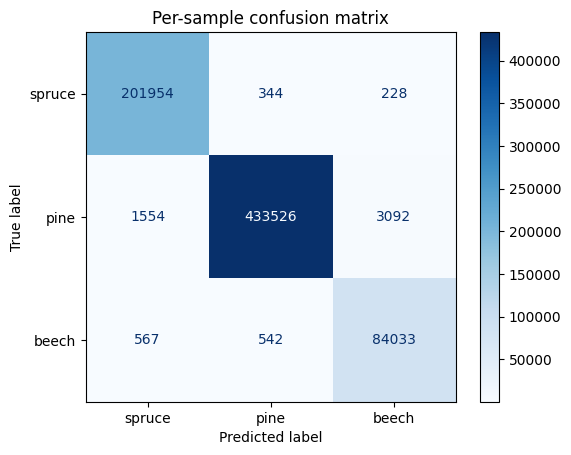

In [20]:
probs, tree_ids, y_true = predict_proba(model=model, loader=test_loader)
y_pred = probs.argmax(axis=1)
df_test["correct"]= (y_pred==y_true)

print("Per-sample accuracy:", accuracy_score(y_true, y_pred))
print("Per-sample classification report")
print(classification_report(y_true, y_pred, target_names=["spruce", "pine", "beech"]))
cm = confusion_matrix(y_true, y_pred)
print("Per-sample confusion matrix:\n", cm)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["spruce", "pine", "beech"]
).plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Per-sample confusion matrix")
plt.show()


### Voyons où se situent les erreurs et les prévisions correctes

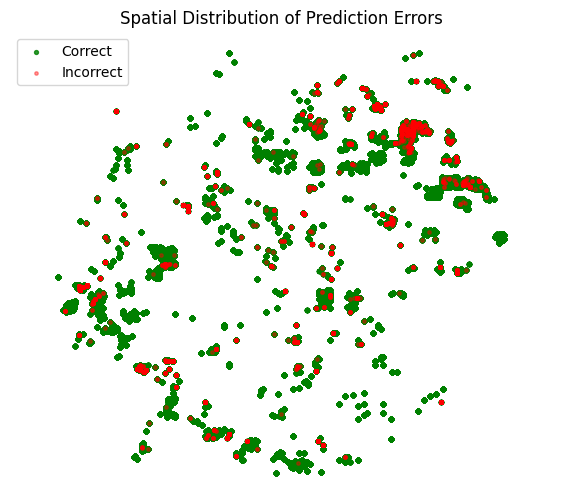

In [21]:
mask = df_test["correct"]

fig, ax = plt.subplots(figsize=(7, 6))

# draw correct points first (background)
ax.scatter(
    df_test.loc[mask, "X_WGS84"],
    df_test.loc[mask, "Y_WGS84"],
    color="green",
    s=8,
    alpha=0.8,
    label="Correct"
)

# draw incorrect points last (on top)
ax.scatter(
    df_test.loc[~mask, "X_WGS84"],
    df_test.loc[~mask, "Y_WGS84"],
    color="red",
    s=6,          # slightly larger helps visibility
    alpha=0.4,
    label="Incorrect"
)

ax.set_title("Spatial Distribution of Prediction Errors")
ax.legend(loc="upper left")
ax.set_xlabel("X (WGS84)")
ax.set_ylabel("Y (WGS84)")
ax.axis("equal")
ax.set_axis_off()
plt.show()



### Agrégeons les probabilités de prédiction (en calculant la moyenne) de tous les échantillons d'arbre et utilisons cette moyenne pour prédire la classe de l'arbre

Per-tree accuracy: 0.9947697225047217
Per-tree classification report
              precision    recall  f1-score   support

      spruce       0.99      1.00      1.00      4054
        pine       1.00      0.99      1.00      8149
       beech       0.98      0.99      0.99      1563

    accuracy                           0.99     13766
   macro avg       0.99      1.00      0.99     13766
weighted avg       0.99      0.99      0.99     13766

Per-tree Confusion matrix:
 [[4051    3    0]
 [  24 8089   36]
 [   7    2 1554]]


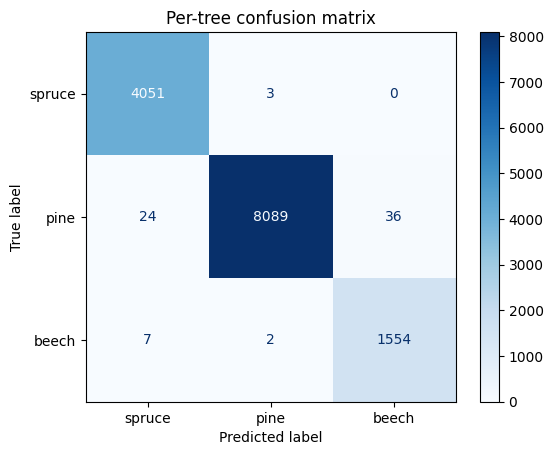

In [22]:
# aggregate mean probs per tree
sum_probs = defaultdict(lambda: np.zeros(3, dtype=np.float64))
count = defaultdict(int)
tree_label = {}

for p, y, tid in zip(probs, y_true, tree_ids):
    sum_probs[tid] += p
    count[tid] += 1
    tree_label[tid] = y  # assumes consistent label per tree

tree_probs = []
tree_y = []
for tid in sum_probs:
    tree_probs.append(sum_probs[tid] / count[tid])
    tree_y.append(tree_label[tid])

tree_probs = np.vstack(tree_probs)
tree_y = np.array(tree_y)
tree_pred = tree_probs.argmax(axis=1)

print("Per-tree accuracy:", accuracy_score(tree_y, tree_pred))
print("Per-tree classification report")
print(classification_report(tree_y, tree_pred, target_names=["spruce", "pine", "beech"]))
cm = confusion_matrix(tree_y, tree_pred)
print("Per-tree Confusion matrix:\n", cm)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["spruce", "pine", "beech"]
).plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Per-tree confusion matrix")
plt.show()

In [23]:
# Convert arrays to a small DataFrame (one row per sample)
pred_df = pd.DataFrame({
    "tree_id": tree_ids,          # per-sample tree_ids from your inference loop
    "y_true": y_true,             # per-sample true labels
})

# tree-level coords from sample-level df_test
tree_coords = (
    df_test.groupby("tree_id", as_index=False)
           .agg(X_WGS84=("X_WGS84", "mean"),
                Y_WGS84=("Y_WGS84", "mean"))
)

# tree-level true label (assumes consistent label per tree)
tree_truth = (
    pred_df.groupby("tree_id", as_index=False)
           .agg(y_true=("y_true", "first"))
)

# tree-level predicted label from your aggregated probs
tree_level = pd.DataFrame({
    "tree_id": list(sum_probs.keys()),
    "tree_pred": tree_pred,
    "tree_y": tree_y
})
tree_level["correct"] = (tree_level["tree_pred"] == tree_level["tree_y"])

# merge everything into one per-tree dataframe
tree_plot = (tree_level
             .merge(tree_coords, on="tree_id", how="left"))

tree_plot.head()


,tree_id,tree_pred,tree_y,correct,X_WGS84,Y_WGS84
0,100,2,2,True,-0.193832,0.126033
1,182,2,2,True,-0.247133,0.135509
2,185,2,2,True,-0.247133,0.135509
3,200,2,2,True,-0.193910,0.135798
4,201,2,2,True,-0.193910,0.135798


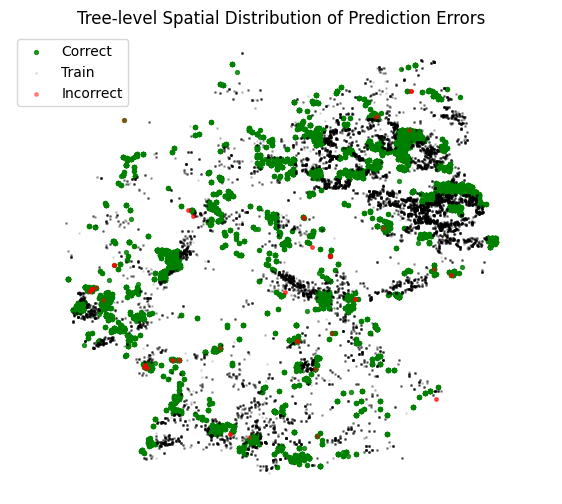

In [24]:
mask = tree_plot["correct"]
fig, ax = plt.subplots(figsize=(7, 6))

train_tree_coords = (
    df_train.groupby("tree_id", as_index=False)
           .agg(X_WGS84=("X_WGS84", "mean"),
                Y_WGS84=("Y_WGS84", "mean"))
)

# draw correct points first
ax.scatter(
    tree_plot.loc[mask, "X_WGS84"],
    tree_plot.loc[mask, "Y_WGS84"],
    color="green",
    s=8,
    alpha=0.8,
    label="Correct"
)

# draw train points on background
ax.scatter(
    train_tree_coords["X_WGS84"],
    train_tree_coords["Y_WGS84"],
    color="black",
    s=1,
    alpha=0.1,
    label="Train"
)

# draw incorrect points last (on top)
ax.scatter(
    tree_plot.loc[~mask, "X_WGS84"],
    tree_plot.loc[~mask, "Y_WGS84"],
    color="red",
    s=6,          # slightly larger helps visibility
    alpha=0.4,
    label="Incorrect"
)


ax.set_title("Tree-level Spatial Distribution of Prediction Errors")
ax.legend(loc="upper left")
ax.set_xlabel("X (WGS84)")
ax.set_ylabel("Y (WGS84)")
ax.axis("equal")
ax.set_axis_off()
plt.show()

### Exercice
J'ai un arbre dont les données sont contenues dans un fichier CSV accessible via la variable "SAMPLE_CSV". Pouvez-vous prédire de quel type d'arbre il s'agit ?

Indice : la réponse devrait être « hêtre » !

In [25]:
n_classes = 3
num_features = 18
model = TreeNet(num_features=num_features, n_classes=n_classes).to(DEVICE)
_, _, tree_scaler = load_checkpoint(model_path=CHECKPOINT, model=model, optimizer=None,
                                    scheduler=None, scaler_path=SCALER_PATH, map_location="cpu")
model.to(DEVICE)

sample_df = pd.read_csv(SAMPLE_CSV)
sample_df = add_time_features(sample_df)
sample_df = tree_scaler.transform(sample_df)
sample_ds = TreeDataset(sample_df, tree_scaler)
sample_loader = DataLoader(sample_ds, batch_size=BATCHSIZE, shuffle=False, num_workers=0, pin_memory=True)

probs, tree_ids, _ = predict_proba(model=model, loader=sample_loader)
sum_probs = defaultdict(lambda: np.zeros(n_classes, dtype=np.float64))
count = defaultdict(int)

for p, tid in zip(probs, tree_ids):
    sum_probs[tid] += p
    count[tid] += 1

tree_probs = {}
for tid in sum_probs:
    tree_probs[tid] = sum_probs[tid] / count[tid]

for tid in tree_probs:
    print(f"Tree {tid} - mean probs:", np.round(tree_probs[tid], 3))
    print(f"Tree {tid} - predicted species:", species_names_nn[int(tree_probs[tid].argmax())])
    print('------------------------------------------------------------')


Tree 0 - mean probs: [0. 0. 1.]
Tree 0 - predicted species: beech
------------------------------------------------------------


### Exercice
Nous avons constaté que le jour de l'année (DoY) et les caractéristiques de structure (hauteur, diamètre à hauteur de poitrine et superficie de la couronne) étaient les moins importantes selon le test d’importance.

De plus, bien que les coordonnées géographiques soient un excellent indicateur, elles pourraient avoir faussé la précision du modèle à cause des patrons de distribution des espèces.

Donc, supprimons les coordonnées, les caractéristiques de structure et le jour de l'année (DoY) de notre jeu de données et voyons comment le modèle se comporte.

Indices: 
- Faites une copie de ce notebook afin de pouvoir l'utiliser comme point de départ.
- Modifiez TreeFeatureScaler pour qu'il ne prenne plus en compte ces variables (peu importe s'il continue à les mettre à l'échelle).
- Modifiez TreeDataset afin que ces variables ne soient plus ajoutées à self.X.